# M9.2A — End-to-end Fourier + camera sin/cos (compact and large)

Plan: [`plans/milestone_09/09_camera_view_fusion_plan.md`](../../plans/milestone_09/09_camera_view_fusion_plan.md).  
**Canonical narrative:** Final Report **M9 Step 2**. This notebook is the **Fourier e2e** ladder (SV / xyz-mean / 09_2 compact / 09_3 large).

**Conclusion:** E2e + geometry abolishes the frozen-encoder Fourier advantage on learned fusion heads.


In [1]:
from pathlib import Path
import shutil
import sys
import subprocess

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not locate repository root containing pyproject.toml")
    ROOT = ROOT.parent

# Concurrent notebook installs race on ./build (Errno 17 File exists).
for name in ("build", "dist"):
    shutil.rmtree(ROOT / name, ignore_errors=True)
for egg in (ROOT / "src").glob("*.egg-info"):
    shutil.rmtree(egg, ignore_errors=True)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-cache-dir",
        f"{ROOT}[dl,dev]",
        "-c",
        str(ROOT / "requirements.txt"),
    ]
)

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")


ROOT=.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from tomography_ml_validation.milestone_09 import describe_paths, m9_corpus_paths

DATA_MODE = "full" if (ROOT / "data/generated/m8_1/single_particle").is_dir() else "demo"
READ_CHECKPOINTS = True
cfg_paths = m9_corpus_paths(ROOT, data_mode=DATA_MODE, read_checkpoints=READ_CHECKPOINTS)
print(f"DATA_MODE={DATA_MODE}")
print(describe_paths(cfg_paths))
print(f"results_dir={display_path(cfg_paths['results_dir'])}")
print(
    f"epochs={cfg_paths['num_epochs']}  stride={cfg_paths['angle_stride_deg']}  "
    f"load_existing={cfg_paths['load_existing']}"
)


DATA_MODE=full
workbook_path=configs/m8/localization_single_particle.xlsx  output_root=data/generated/m8_1/single_particle  cache_root=data/generated/m8_1/single_particle/_cache
results_dir=checkpoints/m9
epochs=200  stride=60.0  load_existing=True


In [3]:
from IPython.display import display

from tomography_ml import get_device
from tomography_ml_validation.milestone_09 import M9E2EConfig, run_m9_e2e_geometry_fusion_family
from tomography_ml_validation.plotting import plot_m9_e2e_rmse_ladder
import tomography_ml_validation.milestone_09.validation as m9_validation
from gummybear_validation.notebook_tools import run_installed_pytest_test

device = get_device()
print(f"device={device}")
run_installed_pytest_test(m9_validation, "test_m9_2_compact_vs_09_3_capacity")


device=mps
M9.2
Test executed: test_m9_2_compact_vs_09_3_capacity()

pytest:
../../venv/lib/python3.12/site-packages/tomography_ml_validation/milestone_09/validation.py . [100%]
============================== 1 passed in 2.12s ===============================

Test proves: 09_3 is a larger fusion MLP than 09_2 under the same e2e protocol.


## Run or load Fourier e2e family


M9 e2e fourier: views=(0.0, 60.0, 120.0, 180.0, 240.0, 300.0)  epochs=200  patience=40  batch=16  lr_stage_a=0.03  SKIP_TRAIN=True
Loaded Stage A from checkpoints/m9/m09_e2e_fourier_geometry_fusion.pt
SKIP_TRAIN: loaded checkpoints/m9/m09_e2e_fourier_geometry_fusion.pt (8 comparison rows)


,variant_id,display_label,fusion_pattern,backbone_kind,n_views,split,encoder_frozen,geometry_tokens,fusion_hidden,fusion_depth,RMSE_total,RMSE_X,RMSE_Y,RMSE_Z,learned_parameter_count,fusion_parameter_count
0,f2a_single_view_reference,SV ref,single_view_reference,fourier,1,test,False,False,NaN,NaN,1.175562,1.374531,0.853540,1.236113,40323,NaN
1,f2a_shared_xyz_mean_control,xyz mean,shared_xyz_mean,fourier,6,test,True,False,NaN,NaN,0.983330,1.163353,0.794488,0.957190,40323,NaN
2,m09_2_e2e_fourier_geometry_fusion,09_2 compact,e2e_fourier_geometry_fusion,fourier,6,test,False,True,128.0,1.0,0.956182,1.053849,0.795101,1.000034,140678,100355.0
3,m09_3_e2e_fourier_geometry_large_fusion,09_3 large,e2e_fourier_geometry_large_fusion,fourier,6,test,False,True,512.0,2.0,1.142814,1.066355,1.002121,1.332934,704390,664067.0
4,f2a_single_view_reference,SV ref,single_view_reference,fourier,1,validation,False,False,NaN,NaN,1.501103,2.015121,1.167621,1.155800,40323,NaN
5,f2a_shared_xyz_mean_control,xyz mean,shared_xyz_mean,fourier,6,validation,True,False,NaN,NaN,1.342990,1.889280,0.917300,1.000025,40323,NaN
6,m09_2_e2e_fourier_geometry_fusion,09_2 compact,e2e_fourier_geometry_fusion,fourier,6,validation,False,True,128.0,1.0,1.288968,1.819971,0.706293,1.083129,140678,100355.0
7,m09_3_e2e_fourier_geometry_large_fusion,09_3 large,e2e_fourier_geometry_large_fusion,fourier,6,validation,False,True,512.0,2.0,1.388657,1.978725,0.909973,1.020637,704390,664067.0


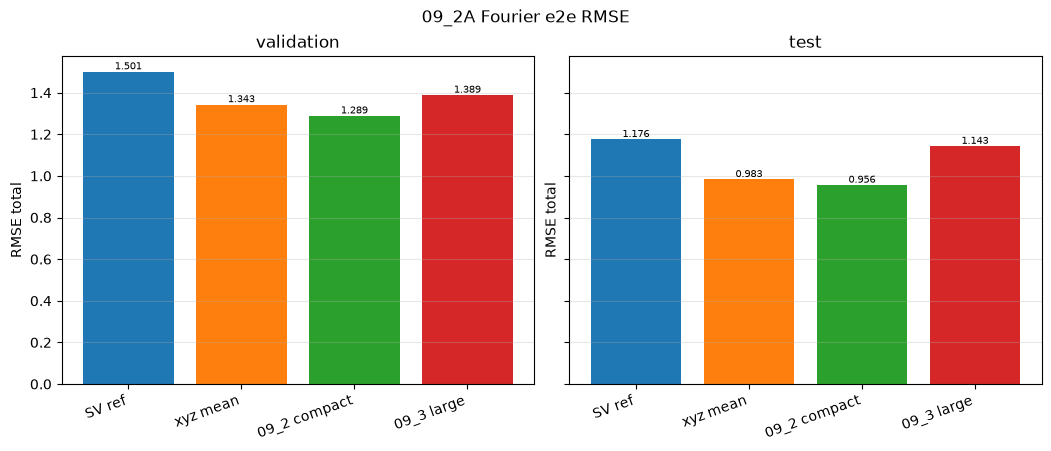

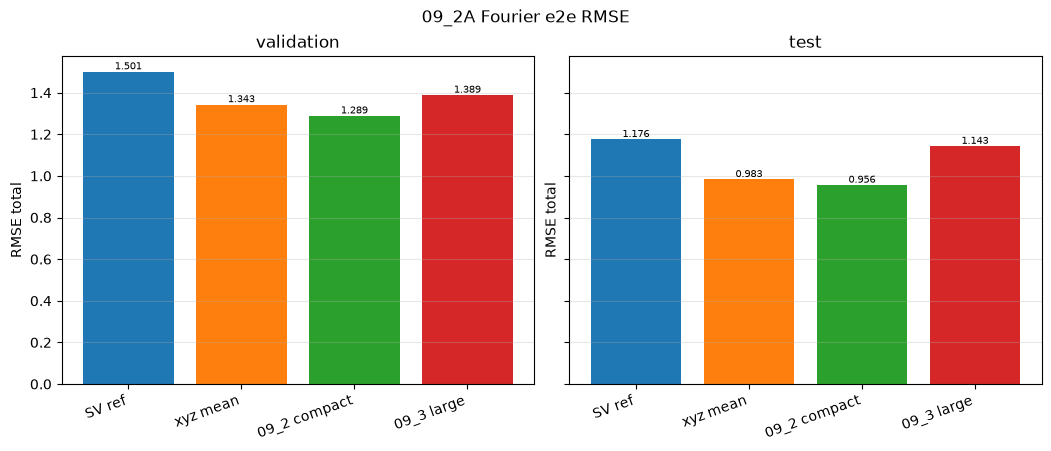

In [4]:
out = run_m9_e2e_geometry_fusion_family(
    M9E2EConfig(
        family="fourier",
        workbook_path=cfg_paths["workbook_path"],
        data_root=cfg_paths["output_root"],
        results_dir=cfg_paths["results_dir"],
        stl_root=ROOT,
        device=device,
        num_epochs=cfg_paths["num_epochs"],
        early_stop_patience=cfg_paths["early_stop_patience"],
        angle_stride_deg=cfg_paths["angle_stride_deg"],
        load_existing=cfg_paths["load_existing"],
        retrain=cfg_paths["retrain"],
    )
)
display(out.comparison_df)
display(plot_m9_e2e_rmse_ladder(out.comparison_df, family="fourier", title="09_2A Fourier e2e RMSE"))


Pooled overlay: `09_2B`. Capacity-only slice: `09_3`.
